In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

# Add the repository root to the python path
sys.path.append(os.path.abspath('/scratch/yl75/ak4177/src/GW_SciML/'))

from src.data.patch_dataset_multi_col import GWPatchDatasetMultiCol

In [2]:
# BASE_DATA_DIR = "/Users/arpitkapoor/Projects/groundwater/data/feflow_data"
BASE_DATA_DIR = "/scratch/yl75/ak4177/data/feflow_data"

PATCH_DATA_DIR = os.path.join(BASE_DATA_DIR, "patch_all_ts")

import torch

# Defining standard targets (e.g. mass concentration, head)
target_col_indices = [0, 1]

# Provide a simple transform to convert numpy arrays to PyTorch tensors 
# this mimics what calculate_obs_transform() does in gino_train.py
def simple_obs_transform(obs_data):
    return torch.tensor(obs_data, dtype=torch.float32)

common_kwargs = dict(
    data_path=PATCH_DATA_DIR,
    dataset='train',
    val_ratio=0.3,
    input_window_size=5,
    output_window_size=1,
    target_col_indices=target_col_indices,
    obs_transform=simple_obs_transform,
    forcings_required=True,
    forcings_transform=simple_obs_transform,
)

In [3]:
print("Loading Original Dataset (no sampling)...")
ds_original = GWPatchDatasetMultiCol(
    **common_kwargs,
    resolution_ratio=1.0,
    sampling_strategy='static',
)

resolution_ratio = 0.3

print(f"\nLoading Static Sampled Dataset ({resolution_ratio*100:.1f}% nodes)...")
ds_static = GWPatchDatasetMultiCol(
    **common_kwargs,
    resolution_ratio=resolution_ratio,
    sampling_strategy='static',
)

Loading Original Dataset (no sampling)...
Static sampling enabled. Uniform patch ratio: 1.0000
Patch 1: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=170
Patch 2: no subsampling (ratio=1.0000). Core nodes=3332, Ghost nodes=332
Patch 3: no subsampling (ratio=1.0000). Core nodes=4312, Ghost nodes=215
Patch 4: no subsampling (ratio=1.0000). Core nodes=2905, Ghost nodes=435
Patch 5: no subsampling (ratio=1.0000). Core nodes=2562, Ghost nodes=128
Patch 6: no subsampling (ratio=1.0000). Core nodes=2898, Ghost nodes=432
Patch 7: no subsampling (ratio=1.0000). Core nodes=4319, Ghost nodes=645
Patch 8: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=340
Patch 9: no subsampling (ratio=1.0000). Core nodes=2569, Ghost nodes=384
Patch 10: no subsampling (ratio=1.0000). Core nodes=3325, Ghost nodes=332
Patch 11: no subsampling (ratio=1.0000). Core nodes=2922, Ghost nodes=292
Patch 12: no subsampling (ratio=1.0000). Core nodes=2202, Ghost nodes=330
Patch 13: no subsampling (

In [4]:
def build_patch_coords(coords_list, coord_key="core_coords"):
    patch_coords = {}
    weights = {}
    for item in coords_list:
        if isinstance(item, dict) and "patch_id" in item:
            pid = item["patch_id"]
            if pid not in patch_coords:
                c = item.get(coord_key)
                if c is not None:
                    patch_coords[pid] = np.asarray(c)
                    weights[pid] = item.get("weights")
            else:
                assert(np.isclose(patch_coords[pid], item.get(coord_key), atol=1e-6).all())
    return patch_coords, weights




In [5]:
coords_orig_map, weights_orig_map = build_patch_coords(ds_original.coords)
coords_stat_map, weights_stat_map = build_patch_coords(ds_static.coords)

In [6]:
# 1. Define the colors array using the tab20 colormap (20 distinct colors)
# Adding a placeholder at index 0 so we can use 1-based indexing (1 to 20)
_COLORS = [None] + list(plt.cm.tab20.colors)

def plot_patches(
    coords_map: dict,
    weights_map: dict,
    title: str = 'Dataset',
    patch_ids=None,
    elev: float = 20,
    azim: float = 190,
    figsize: tuple = (8, 7),
) -> None:
    """Plot all patches from a single dataset as a 3-D scatter plot.

    Parameters
    ----------
    coords_map  : dict mapping patch_id -> (N, 3) coordinate array
    weights_map : dict mapping patch_id -> weight array (may be None)
    title       : figure / axes title string
    patch_ids   : iterable of patch ids to include; defaults to all keys
    elev, azim  : 3-D view angles
    figsize     : (width, height) in inches
    """
    if patch_ids is None:
        patch_ids = sorted(coords_map.keys())

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # running limits to keep axis bounds consistent
    running_min = np.array([np.inf, np.inf, np.inf])
    running_max = np.array([-np.inf, -np.inf, -np.inf])

    total_nodes = sum(coords_map[pid].shape[0] for pid in patch_ids if pid in coords_map)

    for patch_id in patch_ids:
        coords = coords_map.get(patch_id)
        if coords is None:
            continue

        # update running axis limits
        running_min = np.minimum(running_min, coords.min(axis=0))
        running_max = np.maximum(running_max, coords.max(axis=0))

        ax.scatter(
            coords[:, 0], coords[:, 1], coords[:, 2],
            s=6, alpha=1.0, edgecolors='none',
            color=_COLORS[int(patch_id) % len(_COLORS)],
            label=str(patch_id),
        )

    # apply padded axis limits after all patches are plotted
    pad = (running_max - running_min) * 0.05
    pad[pad == 0] = 1.0
    ax.set_xlim(running_min[0] - pad[0], running_max[0] + pad[0])
    ax.set_ylim(running_min[1] - pad[1], running_max[1] + pad[1])
    ax.set_zlim(running_min[2] - pad[2], running_max[2] + pad[2])

    ax.set_title(f'{title}\n{total_nodes} nodes')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(title='Patch ID', bbox_to_anchor=(1.05, 0.88), loc='upper left', fontsize=9)
    ax.set_box_aspect((1, 1, 1.1))
    ax.view_init(elev=elev, azim=azim)
    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

    plt.tight_layout()

    return fig


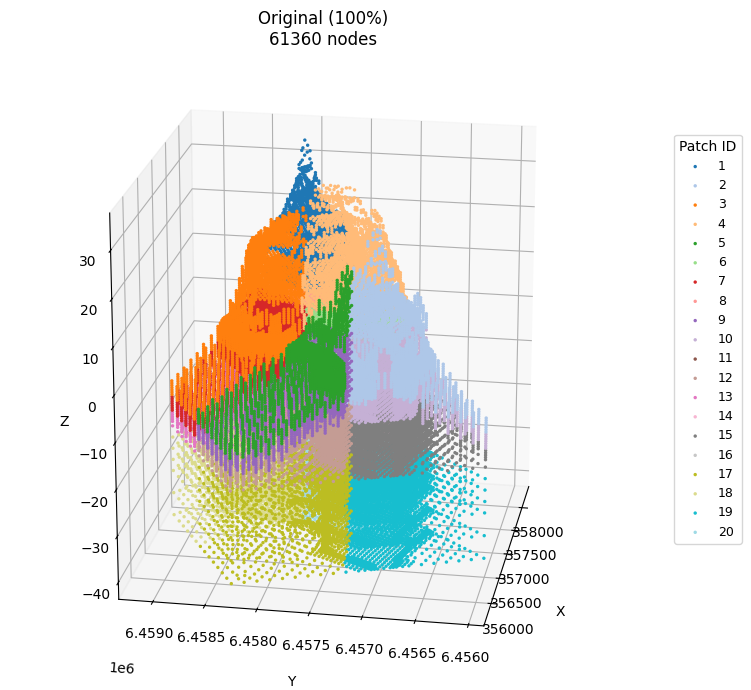

In [7]:
# Plot each dataset as a separate figure using the reusable plot_patches() function
fig = plot_patches(
    coords_map=coords_orig_map,
    weights_map=weights_orig_map,
    title='Original (100%)',
)

fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/high_res_patches.png')

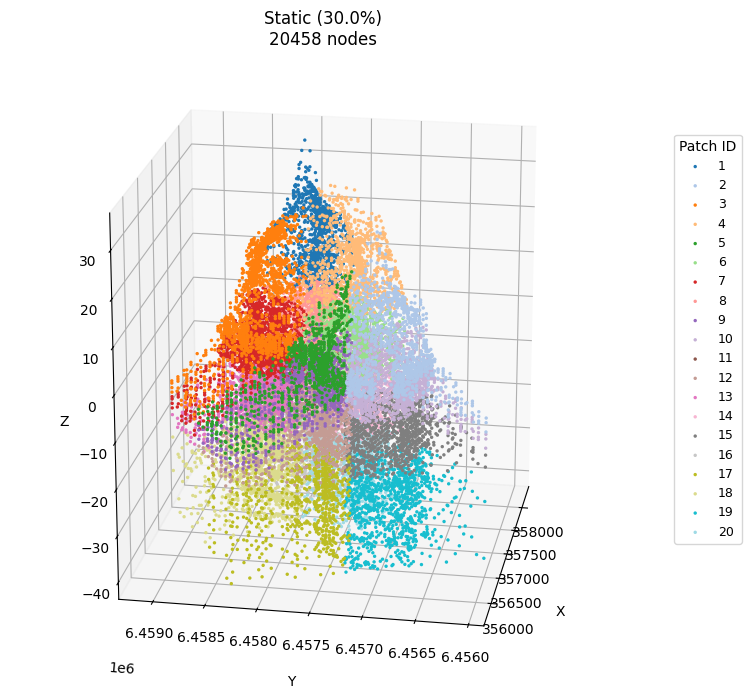

In [8]:
fig = plot_patches(
    coords_map=coords_stat_map,
    weights_map=weights_stat_map,
    title=f'Static ({resolution_ratio*100:.1f}%)',
)

fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/low_res_patches.png')

In [9]:
import pickle

results_dir = '/scratch/yl75/ak4177/results/groundwater/GINO_predictions/'

high_res_dir = os.path.join(results_dir, 'static_sampling/resolution_1.0/gino_predictions_20260713_095614')
low_res_dir =  os.path.join(results_dir, 'standard/resolution_0.3/gino_predictions_20260720_095541')

# Load Targets
high_res_targets = np.load(os.path.join(high_res_dir, 'val_targets.npy'))
high_res_coords = pickle.load(open(os.path.join(high_res_dir, 'train_coords.pkl'), 'rb'))[0]


low_res_targets = np.load(os.path.join(low_res_dir, 'val_targets.npy'))
low_res_coords = pickle.load(open(os.path.join(low_res_dir, 'train_coords.pkl'), 'rb'))[0]

# Apply inverse coordinate transformation
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])

# denormalize coordinates
high_res_denorm_coords = high_res_coords * coord_std + coord_mean
low_res_denorm_coords = low_res_coords * coord_std + coord_mean

In [14]:
high_res_mass_conc = high_res_targets[..., 0]
low_res_mass_conc = low_res_targets[..., 0]

high_res_mass_conc = high_res_mass_conc.transpose((1, 0, 2))
low_res_mass_conc = low_res_mass_conc.transpose((1, 0, 2))

In [23]:
import numpy as np

def plot_targets(
    coords: np.ndarray,
    targets: np.ndarray,
    elev: float = 20,
    azim: float = 190,
    figsize: tuple = (8, 7),
) -> None:
    """Plot all patches from a single dataset as a 3-D scatter plot.

    Parameters
    ----------
    coords_map  : dict mapping patch_id -> (N, 3) coordinate array
    weights_map : dict mapping patch_id -> weight array (may be None)
    title       : figure / axes title string
    patch_ids   : iterable of patch ids to include; defaults to all keys
    elev, azim  : 3-D view angles
    figsize     : (width, height) in inches
    """


    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # Plotting
    sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
                        c=targets[:, -1], cmap='coolwarm', alpha=0.6, s=2)
    plt.colorbar(sc, ax=ax, shrink=0.70)

    # Padding
    
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_zlabel('Z Coordinate (m)')
    ax.set_box_aspect((1, 1, 1.1))
    ax.view_init(elev=elev, azim=azim)
    
    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5
    

    plt.tight_layout()

    return fig


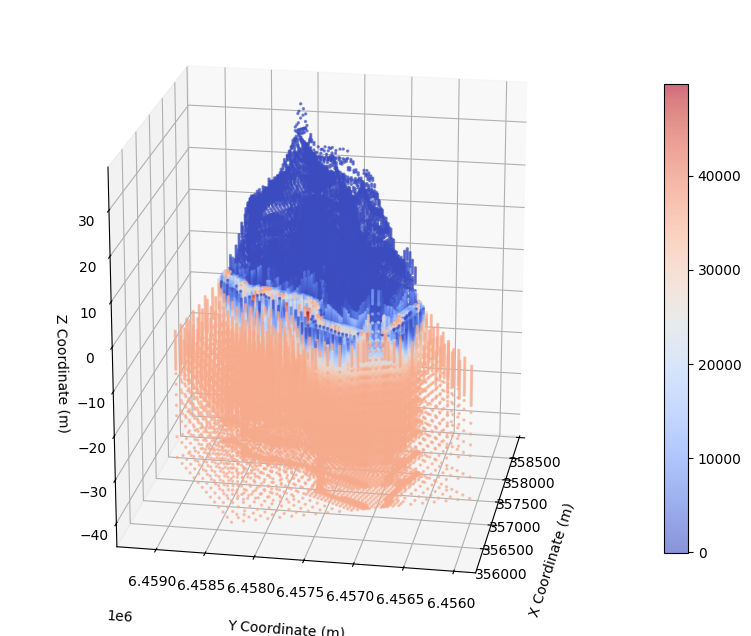

In [25]:
fig = plot_targets(
    coords=high_res_denorm_coords,
    targets=high_res_mass_conc,
)

fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/high_res_mass_conc.png')

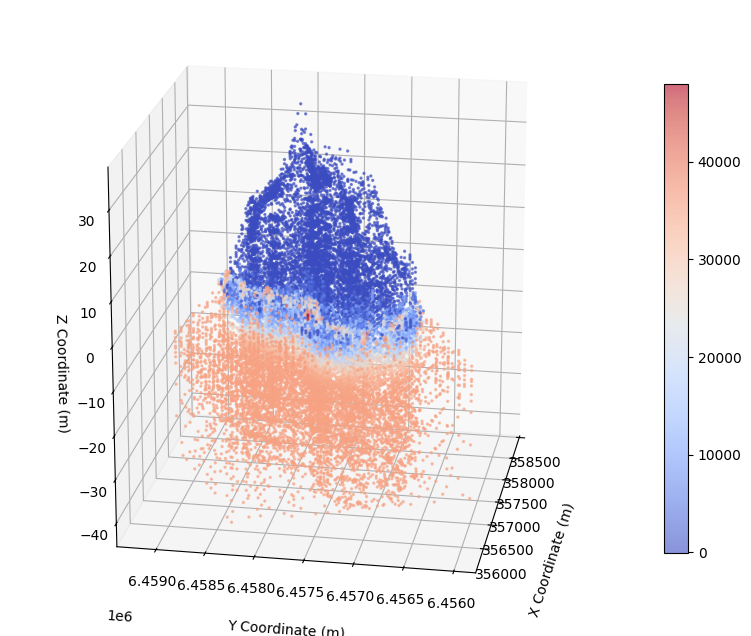

In [26]:
fig = plot_targets(
    coords=low_res_denorm_coords,
    targets=low_res_mass_conc,
)

fig.savefig('/scratch/yl75/ak4177/src/GW_SciML/notebooks/figures/low_res_mass_conc.png')